In [2]:
import os, sys
import numpy as np
import pandas as pd
import pickle as pk
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib as mpl
from itertools import product
from scipy.optimize import curve_fit as cfit

sys.path.insert(0, '../scripts_analysis')
from analysis import *
from peaks import  detect_peaks
from util import *

plt.style.use('dark_background')
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams['font.family'] = 'Noto Sans'

simTypes = {
    'control':     dict(d='control', r='result.dat', v='vesData.dat'),
    'without cross-talk': dict(d='control_eachCa', r='sresult.dat', v='svesData.dat'),
    'syt7KO':      dict(d='syt7KO', r='result.dat', v='vesData.dat'),
    'nonsatBuffer': dict(d='control_unsatBuffer', r='result.dat', v='vesData.dat')
}
#print(simTypes)

resultPath = "../data/"
figPath = "../plots/AP_counting/"
setupLoc = '../model_mcell'

designs = np.genfromtxt(os.path.join(setupLoc, 'representative_designs.txt'), dtype=str)
for i,d in enumerate(designs): print(i, d)

0 nVDCC_2_dVAZ_60_nAZ_15_RRP_35_ISI_20_nAP_10
1 nVDCC_3_dVAZ_100_nAZ_29_RRP_55_ISI_20_nAP_10
2 nVDCC_3_dVAZ_60_nAZ_9_RRP_20_ISI_20_nAP_10
3 nVDCC_3_dVAZ_80_nAZ_35_RRP_30_ISI_20_nAP_10
4 nVDCC_4_dVAZ_100_nAZ_19_RRP_50_ISI_20_nAP_10
5 nVDCC_4_dVAZ_120_nAZ_25_RRP_55_ISI_20_nAP_10
6 nVDCC_4_dVAZ_120_nAZ_33_RRP_50_ISI_20_nAP_10
7 nVDCC_4_dVAZ_80_nAZ_21_RRP_30_ISI_20_nAP_10
8 nVDCC_5_dVAZ_100_nAZ_11_RRP_50_ISI_20_nAP_10
9 nVDCC_5_dVAZ_120_nAZ_15_RRP_50_ISI_20_nAP_10
10 nVDCC_5_dVAZ_120_nAZ_23_RRP_40_ISI_20_nAP_10
11 nVDCC_5_dVAZ_120_nAZ_35_RRP_25_ISI_20_nAP_10
12 nVDCC_5_dVAZ_220_nAZ_35_RRP_50_ISI_20_nAP_10
13 nVDCC_5_dVAZ_80_nAZ_21_RRP_10_ISI_20_nAP_10
14 nVDCC_5_dVAZ_80_nAZ_29_RRP_10_ISI_20_nAP_10
15 nVDCC_6_dVAZ_140_nAZ_25_RRP_30_ISI_20_nAP_10
16 nVDCC_6_dVAZ_160_nAZ_19_RRP_55_ISI_20_nAP_10
17 nVDCC_6_dVAZ_160_nAZ_35_RRP_25_ISI_20_nAP_10
18 nVDCC_6_dVAZ_200_nAZ_29_RRP_50_ISI_20_nAP_10
19 nVDCC_6_dVAZ_80_nAZ_17_RRP_10_ISI_20_nAP_10
20 nVDCC_7_dVAZ_100_nAZ_33_RRP_5_ISI_20_nAP_10
21 nVDCC_7_

# AP probability

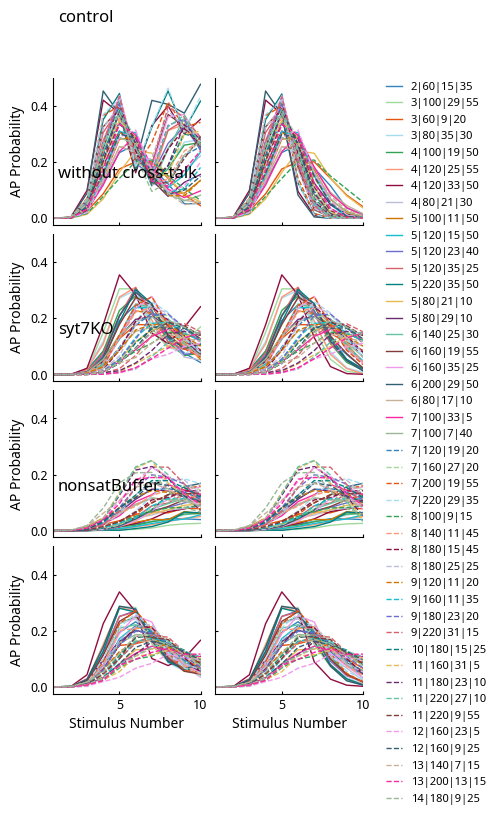

In [3]:
f, ax = plt.subplots(4, 2, sharex=True, sharey=True, figsize=(4,8))
                     #gridspec_kw={'width_ratios': [5, 2]})
f.subplots_adjust(wspace=0.1, hspace=0.06)

ls = ['-', '--']
lw = 1
ISI, nAP = 20, 10
for i,(stlabel,stinfo) in enumerate(simTypes.items()):
    for j,design in enumerate(designs[:]):
        # label = str([int(a) for a in re.findall(r'\d+', design)[:-2]])[1:-1]
        st = stinfo['d']
        # tt = stinfo['tt']
        #print(stlabel)
        # inf = os.path.join(resultPath, st, design, tt+'apTimes.dat')

        if stlabel == 'without cross-talk':
            design = design.split('RRP')[0] + 'ISI' + design.split('ISI')[1]
        ca3p = os.path.join(resultPath, st, design, 'CA3p.pk')
        label = '|'.join(list(getSimInfo(design, skip=0).values())[:-2])
        apProb, ap1Prob = getAPprob(ca3p)

        ## AP Probability
        ax[i,0].plot(range(1,11), apProb, lw=lw, linestyle=ls[int(j/22)], 
                   color=cpall[j%22], label=label)
        ax[i,0].set_ylabel('AP Probability', fontsize=10)

        ## 1st AP
        ax[i,1].plot(range(1, nAP+1), ap1Prob, lw=lw, linestyle=ls[int(j/22)],
                     color=cpall[j%22], label=label)

    ax[i,0].set_xlim(0.9,10)
    # ax[i,0].set_ylim(0,1)
    # ax[i,0].set_yticks([0, 0.5, 1.0])

    ax[i,1].set_xlim(0.9,10)
    # ax[i,1].set_ylim(0, np.ceil(ax[0,1].get_ylim()[1]*9.9)/10)
    # ax[i,1].set_yticks(np.arange(0, np.ceil(ax[0,1].get_ylim()[1]*9.9)/10+0.0001, 0.1))

    ax[i,0].text(1.2, 0.7, stlabel, fontsize=12)

ax[0,1].legend(frameon=False, ncol=1, handlelength=1.4, fontsize=8,
               loc='upper right', bbox_to_anchor=(1.9, 1.04))
ax[-1,0].set_xlabel("Stimulus Number", fontsize=10)
ax[-1,1].set_xlabel("Stimulus Number", fontsize=10)
for axis in ax.ravel():
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'both', which=u'both', length=2, direction='in', labelsize=9)

# plt.savefig(os.path.join(figPath, f'ap_probability.svg'), 
#             dpi=300, bbox_inches='tight', transparent=True)

# All AP Count data-plot

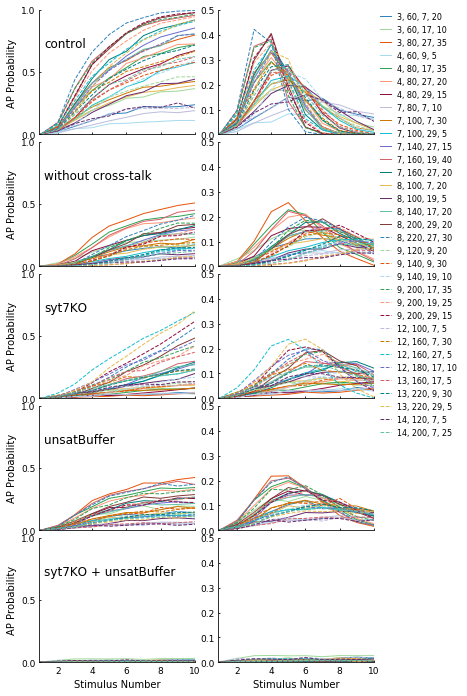

In [14]:
f, ax = plt.subplots(5, 2, sharex=True, figsize=(6,12), squeeze=False)#, gridspec_kw={'width_ratios': [5, 2]})
f.subplots_adjust(wspace=0.15, hspace=0.06)

ls = ['-', '--']
lw = 1
#APth = 100
for i,(stlabel,stinfo) in enumerate(simTypes.items()):
    for j,d in enumerate(dirs[:]):
        ISI, nAP = int(getSimInfo(d, 'ISI')), int(getSimInfo(d, 'nAP'))
        label = str([int(a) for a in re.findall(r'\d+', d)[:-2]])[1:-1]
        st = stinfo['d']
        tt = stinfo['tt']
        #print(stlabel)
        inf = os.path.join(resultPath, st, d, tt+'apTimes.dat')
        apProb, apnProb = getAPprob(inf)
        
        ## AP Probability
        ax[i,0].plot(range(1,11), apProb, lw=lw, linestyle=ls[int(j/17)], 
                   color=cpall[j%17], label=label)
        ax[i,0].set_ylabel('AP Probability', fontsize=10)
        ax[0,0].legend(frameon=False, ncol=1, handlelength=1.4, fontsize=8,
                    loc='upper right', bbox_to_anchor=(2.73, 1.04))
        
        ## 1st AP
        ax[i,1].plot(range(1, nAP+1), apnProb[0], lw=lw, linestyle=ls[int(j/17)],
                     color=cpall[j%17], label=label)

    ax[i,0].set_xlim(0.9,10)
    ax[i,0].set_ylim(0,1)
    ax[i,0].set_yticks([0, 0.5, 1.0])
    
    ax[i,1].set_xlim(0.9,10)
    ax[i,1].set_ylim(0, np.ceil(ax[0,1].get_ylim()[1]*9.9)/10)
    ax[i,1].set_yticks(np.arange(0, np.ceil(ax[0,1].get_ylim()[1]*9.9)/10+0.0001, 0.1))
    
    ax[i,0].text(1.2, 0.7, stlabel, fontsize=12)

ax[-1,0].set_xlabel("Stimulus Number", fontsize=10)
ax[-1,1].set_xlabel("Stimulus Number", fontsize=10)
for axis in ax.ravel():
    axis.spines["right"].set_visible(False)
    axis.spines["top"].set_visible(False)
    axis.tick_params(axis=u'both', which=u'both', length=2, direction='in', labelsize=9)

#plt.savefig(os.path.join(figPath, f'apAll_{simType}.eps'), fmt='eps', dpi=300, bbox_inches='tight', transparent=True)

# Single case data-plot

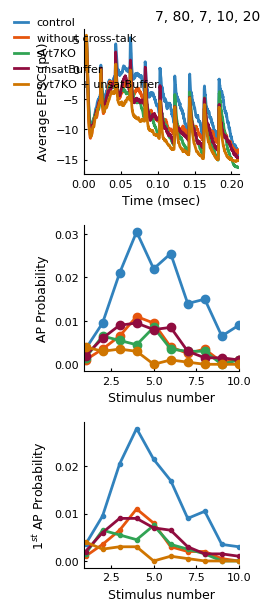

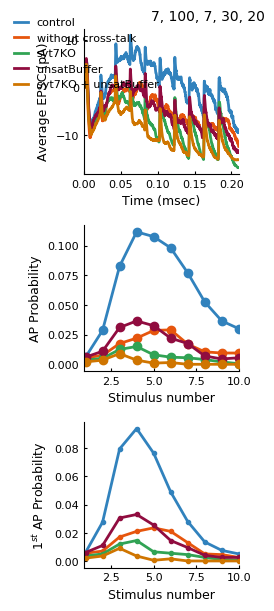

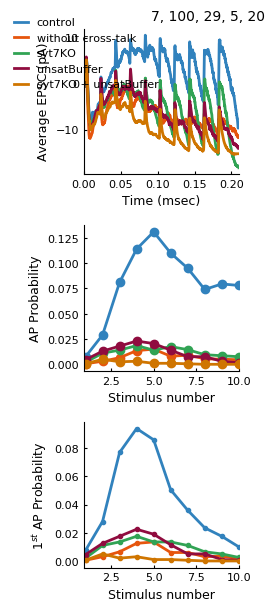

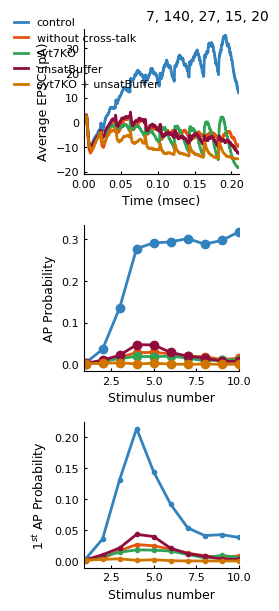

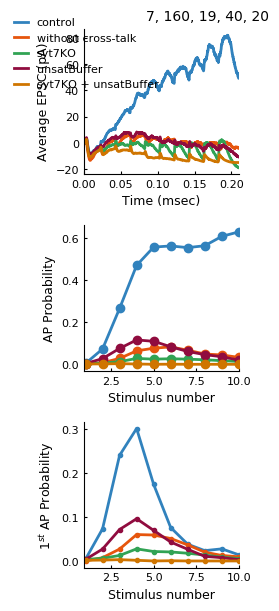

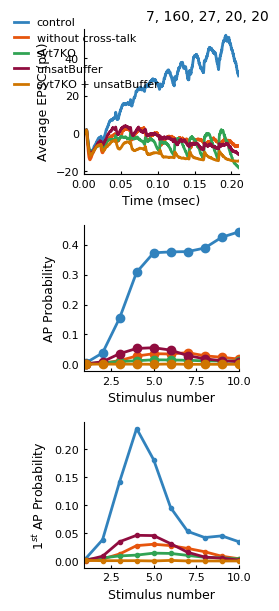

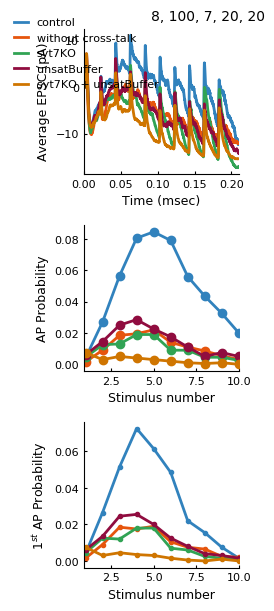

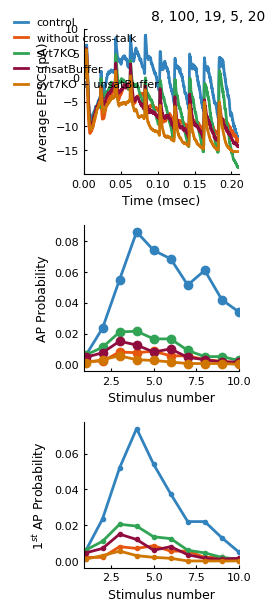

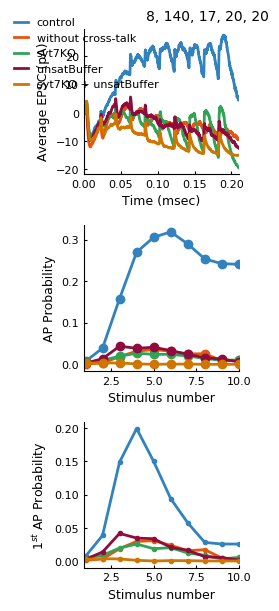

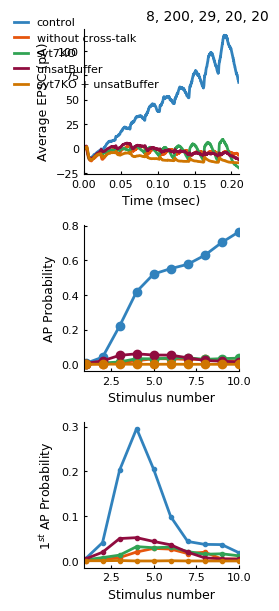

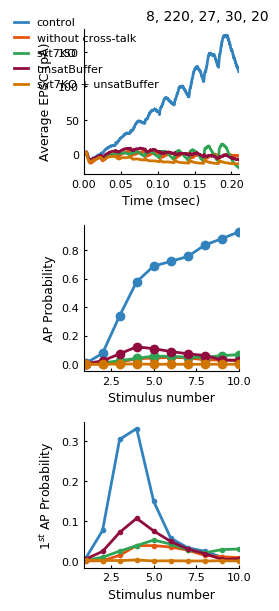

In [23]:
lw = 2
for i,d in enumerate(dirs[7:18]):
    label = str([int(a) for a in re.findall(r'\d+', d)[:-2]])
    f, ax = plt.subplots(3, 1, sharex=False, figsize=(2,7))
    f.subplots_adjust(wspace=1, hspace=0.35)
    
    for i,(stlabel,stinfo) in enumerate(simTypes.items()):
        st = stinfo['d']
        tt = stinfo['tt']

        inf = os.path.join(resultPath, st, d, tt+'apTimes.dat')
        apProb, apnProb = getAPprob(inf)
        
        ## Average EPSC
        avgEPSC = np.genfromtxt(os.path.join(resultPath, st, d, tt+'epsc.dat'), unpack=True)
        ax[0].plot(*avgEPSC, lw=lw, color=cpdark[i], label=stlabel)
        ax[0].set_ylabel('Average EPSC (pA)', fontsize=9)
        ax[0].set_xlabel('Time (msec)', fontsize=9)
        ax[0].set_xlim(0, 0.21)
        ax[0].set_xticks(np.arange(0, 0.21, 0.05))
        ax[0].legend(loc='lower right', bbox_to_anchor=(0.51, 0.55), fontsize=8,
                     ncol=1, borderaxespad=0, frameon=False, handlelength=1.2)

        ## AP Probability
        ax[1].plot(range(1,11), apProb, 'o-', lw=lw, color=cpdark[i], label=stlabel)
        ax[1].set_ylabel('AP Probability', fontsize=9)
        ax[1].set_xlabel('Stimulus number', fontsize=9)
        ax[1].set_xlim(0.9, 10)
        
        ## First AP
        ax[2].plot(range(1,11), apnProb[0], '.-', lw=lw, color=cpdark[i])
        ax[2].set_ylabel('$1^{st}$ AP Probability', fontsize=9)
        ax[2].set_xlabel('Stimulus number', fontsize=9)
        ax[2].set_xlim(0.9, 10)
        
    ax[0].set_title(str([int(a) for a in re.findall(r'\d+', d)[:-1]])[1:-1], x=0.8, fontsize=10)
    for axis in ax:
        axis.spines["right"].set_visible(False)
        axis.spines["top"].set_visible(False)
        axis.tick_params(axis=u'both', which=u'both', length=2, direction='in', labelsize=8)

plt.show()
#plt.savefig(os.path.join(figPath, f'ap_{d}.eps'), fmt='eps', dpi=300, bbox_inches='tight', transparent=True)

## L-M-H 4D plot for AP Probability

In [10]:
nVDCCr = dict(low=[2, 5],
              mid=[6, 10],
              high=[11, 14])

dVDCCr = dict(low=[60, 110],
              mid=[120, 160],
              high=[170, 220])

nAZr  = dict(low=[7, 14],
             mid=[15, 21],
             high=[24, 29])

RRPr  = dict(low=[5, 16],
             mid=[17, 28],
             high=[29, 40])
#'''
i=1

# nV dV nAZ RRP
ct = {
    'low': 0,
    'mid': 1,
    'high': 2
}
ncases = np.zeros((3,3,3,3))
for d in tempdirs:
    nv  = int(getSimInfo(d, 'nVDCC'))
    dv  = int(getSimInfo(d, 'dVDCC'))
    naz  = int(getSimInfo(d, 'nAZ'))
    rrp = int(getSimInfo(d, 'RRP'))
    #print(nv, dv, naz, rrp)
    
    for k, r in nVDCCr.items():
        if nv>=r[0] and nv<=r[1]:
            nvk = k
            continue
            
    for k, r in dVDCCr.items():
        if dv>=r[0] and dv<=r[1]:
            dvk = k
            continue
            
    for k, r in nAZr.items():
        if naz>=r[0] and naz<=r[1]:
            nazk = k
            continue
            
    for k, r in RRPr.items():
        if rrp>=r[0] and rrp<=r[1]:
            rrpk = k
            continue
    
    ## AP Probability
    inf = os.path.join(resultPath, 'control_eachCa', d, 'aapTimes.dat')
    apProb, apnProb = getAPprob(inf)
    #print(app)
    ncases[ct[nvk], ct[dvk], ct[nazk], ct[rrpk]] = max(apProb)
print(ncases)

[[[[0.1125 0.2385 0.    ]
   [0.3685 0.     0.7225]
   [0.673  0.727  0.7985]]

  [[0.     0.     0.    ]
   [0.     0.     0.    ]
   [0.     0.     0.    ]]

  [[0.     0.     0.    ]
   [0.     0.     0.    ]
   [0.     0.     0.    ]]]


 [[[0.1915 0.3945 0.4255]
   [0.444  0.     0.    ]
   [0.579  0.     0.    ]]

  [[0.     0.464  0.5795]
   [0.597  0.8065 0.9565]
   [0.855  0.9195 0.    ]]

  [[0.     0.     0.    ]
   [0.     0.945  0.966 ]
   [0.9785 0.9785 0.997 ]]]


 [[[0.2185 0.     0.    ]
   [0.     0.     0.    ]
   [0.     0.     0.    ]]

  [[0.253  0.     0.669 ]
   [0.6235 0.     0.    ]
   [0.9095 0.     0.    ]]

  [[0.     0.6265 0.718 ]
   [0.808  0.     0.    ]
   [0.92   0.     0.    ]]]]


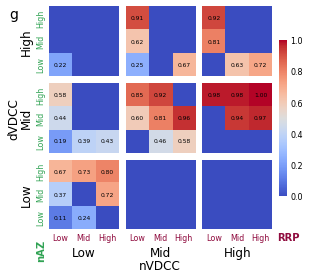

In [11]:
f, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(5,4.1))
f.subplots_adjust(wspace=0.1, hspace=0.1)

cases = ['Low', 'Mid', 'High']
for axis in ax[-1,:]:
    axis.set_xticks(range(3))
    axis.set_xticklabels(cases, color=cpdark[3], fontsize=8)

for axis in ax[:,0]:
    axis.set_yticks(range(3))
    axis.set_yticklabels(cases, color=cpdark[2], fontsize=8, 
                         rotation=90, ha="right", va="center")

for nv, dv in product(range(3), range(3)):
    ax[nv][dv].tick_params(axis=u'both', which=u'both',length=0)
    
    imdata = ncases[2-nv, dv]
    im = ax[nv][dv].imshow(imdata, vmin=0, vmax=1, 
                           cmap='coolwarm', origin='lower')
    for i in range(3):
        for j in range(3):
            if imdata[i, j] > 0.001:
                text = ax[nv][dv].text(j, i, f'{imdata[i, j]:0.2f}', fontsize=6,
                                       ha="center", va="center", color="black")
    if nv==2:
        ax[nv][dv].set_xlabel(cases[dv], fontsize=12)
    if dv==0:
        ax[nv][dv].set_ylabel(cases[2-nv], fontsize=12)
       
    ax[nv][dv].spines["bottom"].set_visible(False)
    ax[nv][dv].spines["top"].set_visible(False)
    ax[nv][dv].spines["right"].set_visible(False)
    ax[nv][dv].spines["left"].set_visible(False)
    
ax[-1,0].text(-1.05, -1.8, 'nAZ', size=10, rotation=90, color=cpdark[2], fontweight='bold')
ax[-1,-1].text(2.7, -0.96, 'RRP', size=10, color=cpdark[3], fontweight='bold')
ax[-1,1].text(0.05, -2.2, 'nVDCC', size=12, color=cpdark[-1])
ax[1,0].text(-2.3, 0.2, 'dVDCC', size=12, rotation=90, color=cpdark[-1])
ax[0,0].text(-2.2, 2, 'g', fontsize=14)

cb = f.colorbar(im, ax=ax.ravel().tolist(), shrink=0.7, anchor=(-0.2,0.5))
cb.outline.set_visible(False)
cb.ax.tick_params(size=0, labelsize=8)

#f.savefig(os.path.join(figPath, 'APprob_4D.eps'), fmt='eps',
#          dpi=300, bbox_inches='tight', transparent=True)

# Trial